In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
#%load_ext line_profiler
#%load_ext snakeviz
%autoreload 2

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import corner

import pickle

import enterprise
from enterprise.pulsar import Pulsar
import enterprise.signals.parameter as parameter
from enterprise.signals import utils
from enterprise.signals import signal_base
from enterprise.signals import selections
from enterprise.signals.selections import Selection
from enterprise.signals import white_signals
from enterprise.signals import gp_signals
from enterprise.signals import deterministic_signals
import enterprise.constants as const

from enterprise_extensions import deterministic

from scipy.stats import norm

import libstempo as T2
import libstempo.toasim as LT
import libstempo.plot as LP

import glob
import json
import h5py
import healpy as hp
import scipy.constants as sc
import emcee

from numba.typed import List

import sys
import h5py
from enterprise_extensions import model_utils
from matplotlib import colors
from scipy.stats import gaussian_kde
from matplotlib.ticker import ScalarFormatter
from matplotlib import colors

In [2]:
#COMMENT IF OUTFILE GENERATED
#Thinning script for one source
i = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D1_broad_UL_1e9_fixed_gamma_outfile.h5"

infile = i
first_n_param = 8
# outfile = '/scratch/na00078/QuickCW_targeted_runs/results/3C66B_outfile.h5'

print(infile)
print(first_n_param)

with h5py.File(infile, 'r') as f:
    Ts = f['T-ladder'][...]
    samples_cold = f['samples_cold'][:,:,:first_n_param]
    print(samples_cold[-1].shape)
    log_likelihood = f['log_likelihood'][:1,:]
    print(log_likelihood.shape)
    par_names = [x.decode('UTF-8') for x in list(f['par_names'])]
    acc_fraction = f['acc_fraction'][...]
    fisher_diag = f['fisher_diag'][...]

/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D1_broad_UL_1e9_fixed_gamma_outfile.h5
8
(100000000, 8)
(1, 100000000)


In [3]:
#Enter dL value

target_d_L = 75.4

hamp [1.85066690e-18 1.61623916e-18 7.00494342e-16 ... 6.39488665e-14
 7.27513718e-15 1.10389496e-16]
freq [7.6379116e-09 1.3127951e-08 6.4759305e-09 ... 6.7425852e-08 3.1916128e-09
 6.7425852e-08]
mc [8.7217619e+10 1.8786533e+10 6.2201975e+10 ... 3.7523525e+09 9.6521257e+10
 3.7523525e+09]
Length of logdL 100000000
required values 8.810465 5.188435e-09 21712937000.0 1.6790009e-15
dL min 74.646
dL max 76.15400000000001
10**log10_d_L [2.1361502e+08 2.7164842e+07 2.8781100e+05 ... 1.3948505e+02 3.5961723e+04
 8.0804031e+04]
min 10**log10_d_L 0.0019837243
max 10**log10_d_L 646345660.0
d_L_mask [   53528    53529    53531 ... 99933102 99940799 99941217]
notd_L_mask1 [   49654    49716    49718 ... 99995243 99999332 99999678]
notd_L_mask2 [       0        1        2 ... 99999997 99999998 99999999]
merged_non_dL [   49654    49716    49718 ... 99999997 99999998 99999999]


Sample shape (100000000, 9)
dL_mask length 20541
6
Max Mc sampled 10.035845


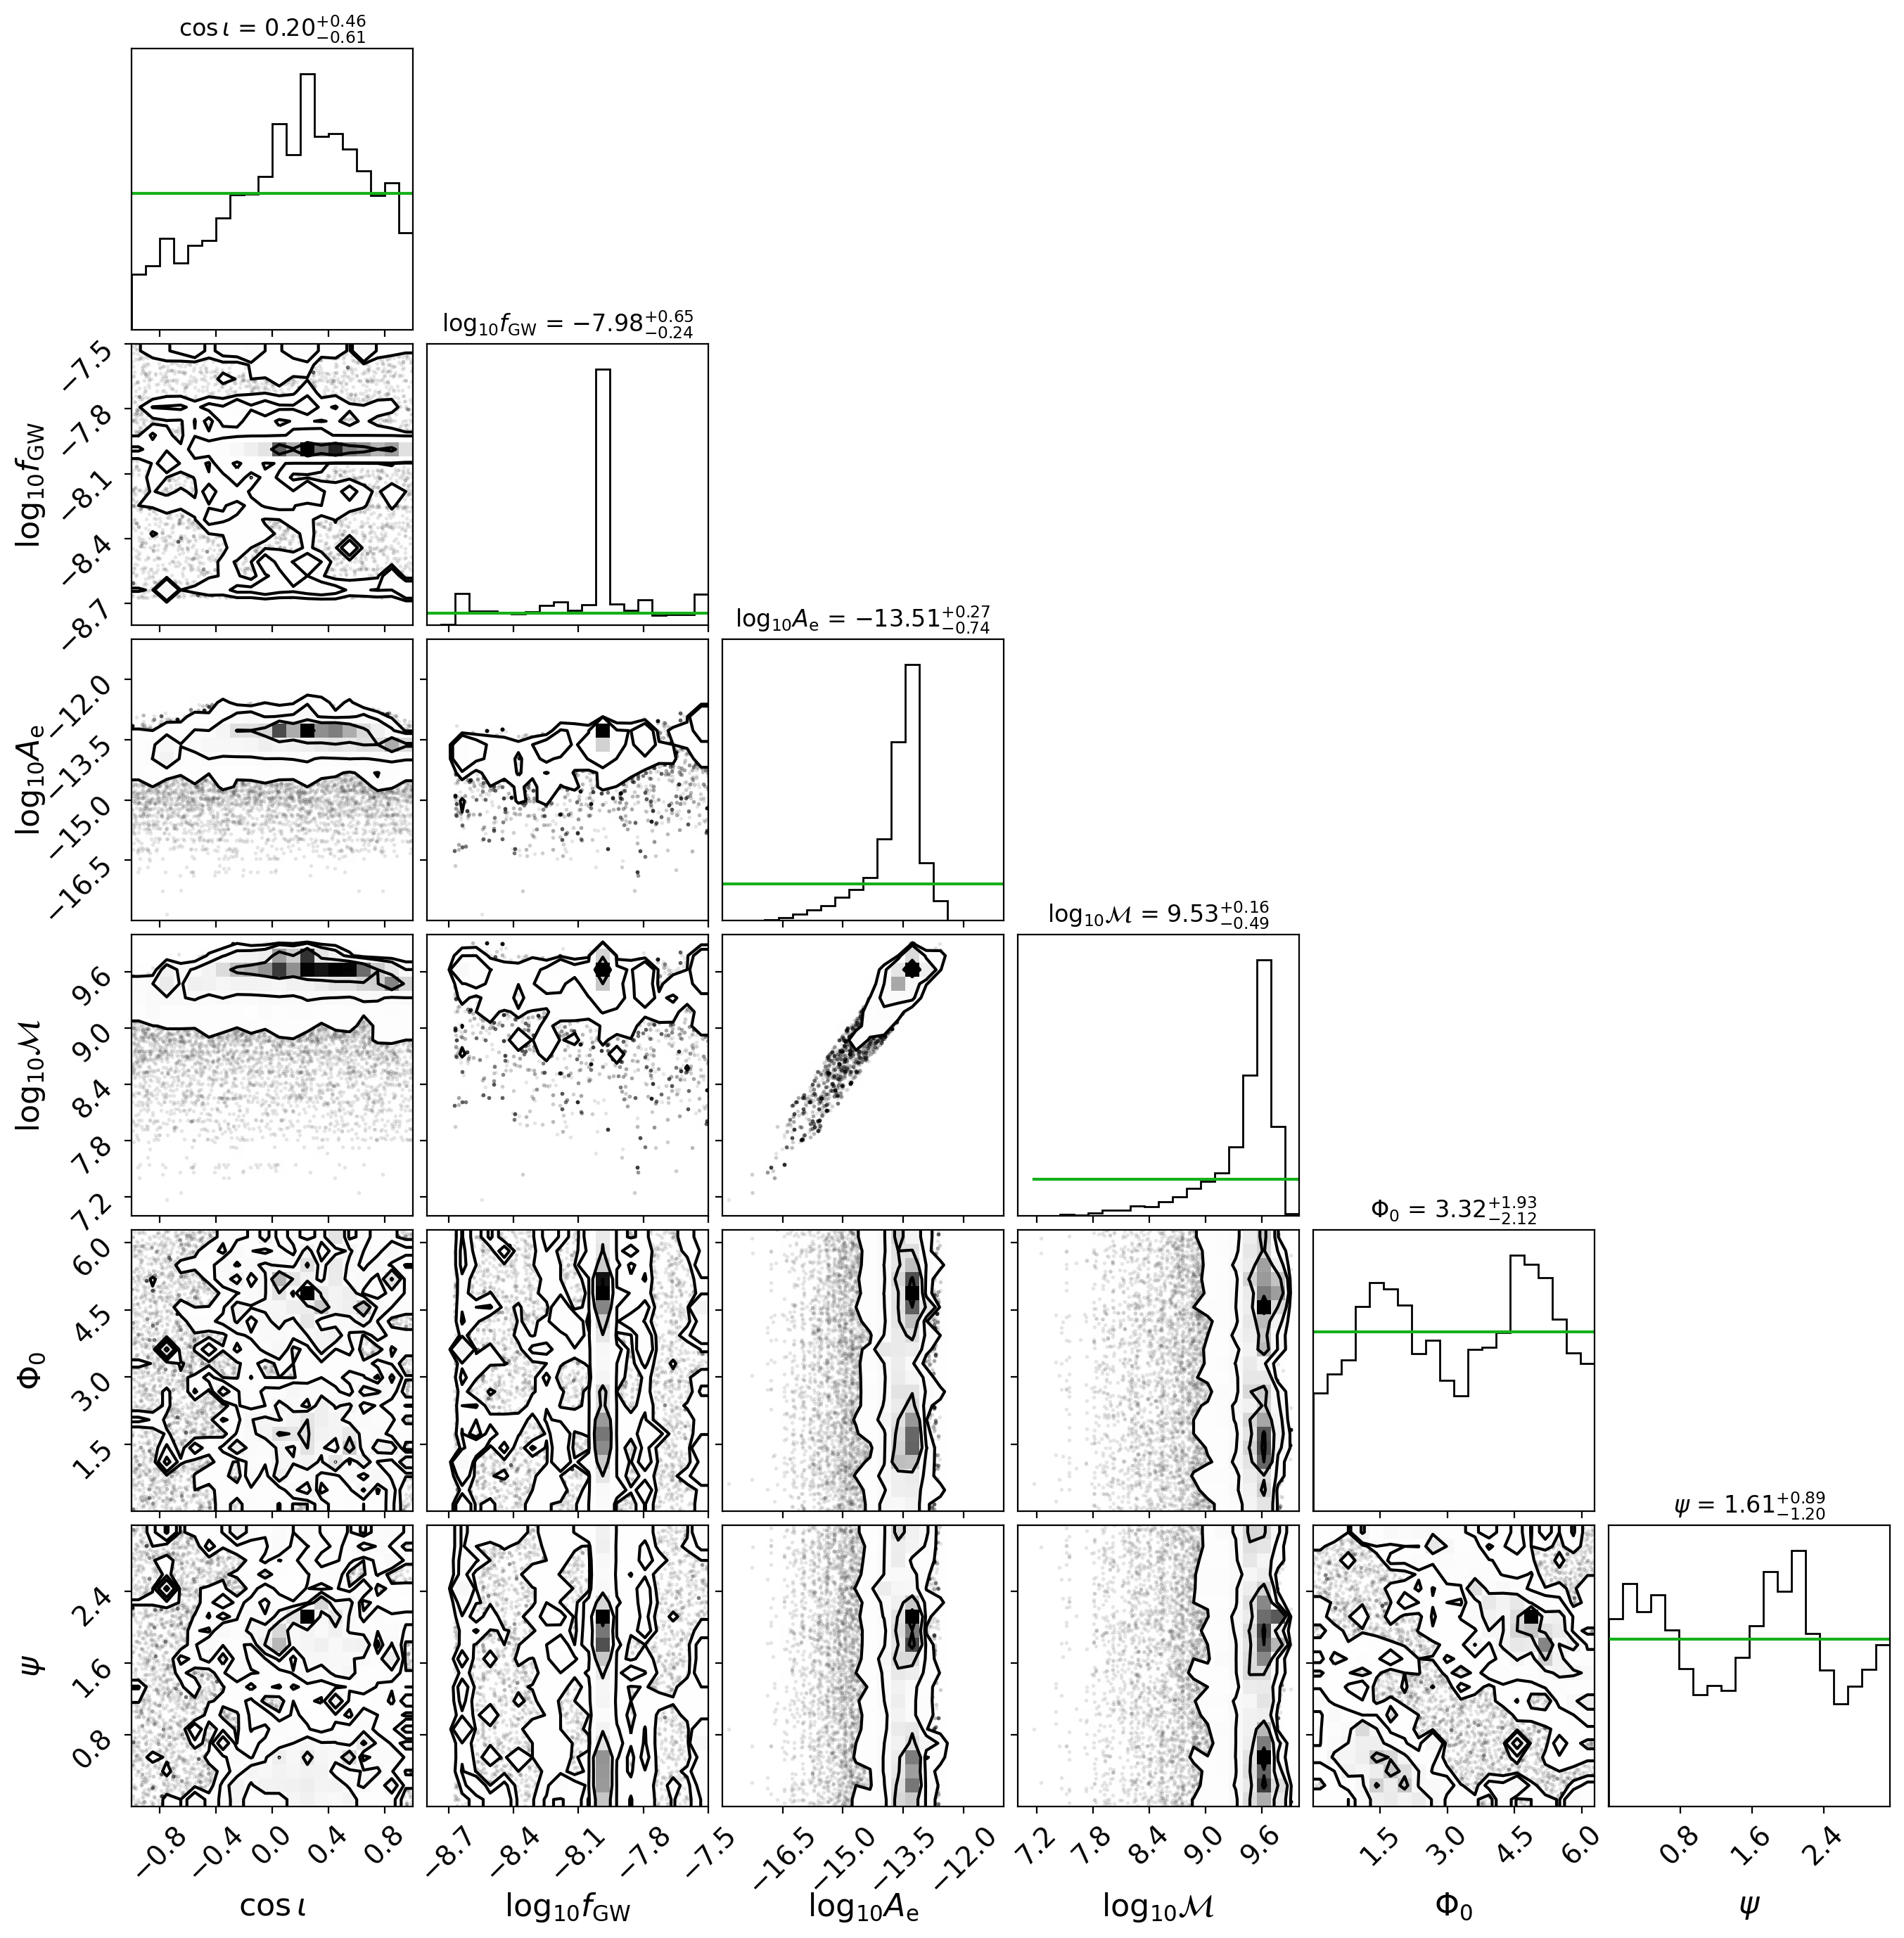

In [4]:
#corner plot of parameters common to all pulsars (Contains Luminosity distance)
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
par_keys = ["0_cos_gwtheta", "0_cos_inc", "0_gwphi", "0_log10_fgw",
          "0_log10_h", "0_log10_mc", "0_phase0", "0_psi","log10_d_L"]
#labels = [r"$\cos \theta$", r"$\cos \iota$", r"$\phi$", r"$\log_{10} f_{\rm GW}$",
      #    r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$", r"$\psi$",r"$\log_{10} d_L$"]
labels = [r"$\cos \iota$", r"$\log_{10} f_{\rm GW}$", r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$",r"$\psi$"]

label_to_key = {
    r"$\cos \iota$": "0_cos_inc",
     r"$\log_{10} f_{\rm GW}$":"0_log10_fgw",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "phase0",
    r"$\psi$": "psi"
}

# Now build the truths array by translating labels
#truths = [xxx[label_to_key[l]] for l in labels]


#set burnin and thinning
#burnin = 0
#burnin = 500_000
burnin = 0#int(1e6)
thin = 1

#set ranges
ranges = [(-1,1), (-8.8,-7.5), (-18,-11), (7,10), (0,2*np.pi), (0,np.pi)]
#ranges = [(-1,1), (-1,1), (0,2*np.pi), (-8.704,np.log10(3e-7)), (-18,-11), (6.6,12), (0,2*np.pi), (0,np.pi), (0,10)]
#ranges = [0.99]*9


megaparsec = 3.086e+22 #meter
speed_of_light = 299792458.0 #m/s
T_sun = 1.327124400e20 / speed_of_light**3 #G*M_sun/c^3 = R_sun/c-->Sun time

############################################################################
h_amp = 10**samples_cold[0][burnin::thin,4]
fff = 10**samples_cold[0][burnin::thin,3]
mmm = 10**samples_cold[0][burnin::thin,5]

print('hamp',h_amp)
print('freq',fff)
print('mc',mmm)

log10_d_L = np.log10(2 * (mmm*T_sun)**(5/3) * (np.pi*fff)**(2/3) / h_amp *speed_of_light/megaparsec)
print("Length of logdL", len(log10_d_L))
print("required values",np.max(log10_d_L), fff[1000], mmm[1000], h_amp[1000] )
#####################################

d_L_percent_tolerance = 1.0
#####################################

d_L_min = target_d_L*(1-d_L_percent_tolerance/100)
d_L_max = target_d_L*(1+d_L_percent_tolerance/100)
print("dL min",d_L_min)
print("dL max",d_L_max)
print("10**log10_d_L",10**log10_d_L)
print("min 10**log10_d_L",np.min(10**log10_d_L))
print("max 10**log10_d_L",np.max(10**log10_d_L))

d_L_mask = np.where((10**log10_d_L>=d_L_min) & (10**log10_d_L<=d_L_max))[0]
print("d_L_mask",d_L_mask)

#########################
not_d_L_mask_1 = np.where((10**log10_d_L<d_L_min))[0] #& (10**log10_d_L>d_L_max))[0]
print("notd_L_mask1",not_d_L_mask_1)
not_d_L_mask_2 = np.where((10**log10_d_L>d_L_max))[0] #& ())[0]
print("notd_L_mask2",not_d_L_mask_2)

merged_non_dL = np.concatenate((not_d_L_mask_1,not_d_L_mask_2))
print("merged_non_dL",merged_non_dL)
########################################

samples2plot = np.concatenate((samples_cold[0][burnin::thin,corner_mask], np.array([log10_d_L,]).T), axis=1)

print("Sample shape", samples2plot.shape)
print("dL_mask length", len(d_L_mask))
print(len(ranges))

print("Max Mc sampled", np.max(samples2plot[d_L_mask,5]))

samples2plot_detect = np.vstack((
                          samples2plot[d_L_mask,1],
                            samples2plot[d_L_mask,3],
                          samples2plot[d_L_mask,4],
                          samples2plot[d_L_mask,5],
                          samples2plot[d_L_mask,6],
                          samples2plot[d_L_mask,7])).T


#fig = corner.corner(samples2plot_detect,
  #                  labels=labels,
   #                 show_titles=True, quantiles=[0.16, 0.5, 0.84],
    #                range=ranges, hist_kwargs={"density":True})
    
fig = corner.corner(
    samples2plot_detect,
    labels=labels,
    show_titles=True,
    range=ranges,
    hist_kwargs={"density": True})

for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=14)   # tick labels
    ax.xaxis.label.set_size(16)                 # x-axis label
    ax.yaxis.label.set_size(16)                 # y-axis label

#plot priors over 1D posteriors
for i, ax in enumerate(fig.axes):
    if i==0:#(len(labels)+1): #cos inc and cos theta
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    elif i==(len(labels)+1): #log10_fgw
         Xs = np.linspace(-9, np.max(samples2plot[d_L_mask,3]))
         ax.plot(Xs, Xs*0+1/3, color="xkcd:green")
    elif i==2*(len(labels)+1): #log10_A
        Xs = np.linspace(-18, -11)
        ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==3*(len(labels)+1): #log10_M_ch
        Xs = np.linspace(np.min(samples2plot[d_L_mask,5]), np.max(samples2plot[d_L_mask,5]))
        ax.plot(Xs, Xs*0+1/3, color="xkcd:green")
    elif i==4*(len(labels)+1): #gwphi and phase0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==5*(len(labels)+1): #psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")

#fig.suptitle(crnr_plt_title1, fontsize = 25,y=1.05);

In [5]:
def compute_frequency_bins(samples_log10_fgw, samples_log10_mc, years, mask=None,
                           mode="step", nbins=None):
    """
    Compute number of frequency bins, frequency threshholds, sample indices, and chirp mass indices by bin.

    Parameters
    ----------
    samples_log10_fgw : array
        log10 of GW frequencies from MCMC samples.
    samples_log10_mc : array
        log10 of chirp mass from MCMC samples.
    years : float
        Data span in years.
    mask : array-like, optional
        Boolean or index mask to select subset of samples.
    mode : str, optional
        "step"  -> bins spaced by df = 1/Tspan (default).
        "nbins" -> use a fixed number of bins between fmin and fmax.
    nbins : int, optional
        Required if mode="nbins". Number of bins.

    Returns
    -------
    nbins : int
        Number of bins.
    f_bin_edges : ndarray
        Bin edges in Hz.
    bin_indices : list of arrays
        Indices of samples in each bin.
    mc_by_bin : list of arrays
        Chirp mass values corresponding to samples in each bin.
    """
    # Apply mask if given
    if mask is not None:
        fgw = 10**samples_log10_fgw[mask]
        mc  = 10**samples_log10_mc[mask]
    else:
        fgw = 10**samples_log10_fgw
        mc  = 10**samples_log10_mc

    # Frequency range
    fmin, fmax = fgw.min(), fgw.max()
    print("fmin, fmax",np.log10(fmin), np.log10(fmax))

    # Bin edges depending on mode
    if mode == "step":
        Tspan = years * 365.25 * 24 * 3600
        df = 1.0 / Tspan
        print("df",np.log10(df))
        f_bin_edges = np.arange(fmin, fmax+df , df)
        nbins = len(f_bin_edges) - 1

    elif mode == "nbins":
        if nbins is None:
            raise ValueError("You must provide nbins when mode='nbins'")
        f_bin_edges = np.linspace(fmin, fmax, nbins + 1)

    else:
        raise ValueError("mode must be 'step' or 'nbins'")

    # Assign samples to bins
    inds = np.digitize(fgw, f_bin_edges) - 1
    bin_indices = [np.where(inds == i)[0] for i in range(len(f_bin_edges)-1)]

    # Collect chirp mass values by bin
    mc_by_bin = [mc[idx] for idx in bin_indices]

    return nbins, f_bin_edges, bin_indices, mc_by_bin


In [6]:
def compute_UL_per_bin(mc_by_bin, conf=0.95, plot=False):
    """
    Compute number of samples, UL, and UL error per frequency bin.

    Parameters
    ----------
    mc_by_bin : list of arrays
        Each element contains the sample values (e.g., Mc) for one frequency bin.
    conf : float
        Confidence level for UL (default = 0.95).
    plot : bool
        If True, show diagnostic histograms for each bin.

    Returns
    -------
    counts_per_bin : list of int
        Number of samples in each bin.
    ULs : list of float
        Upper limits per bin at given confidence.
    UL_errors : list of float
        Error estimates on ULs.
    """
    counts_per_bin = []
    ULs = []
    UL_errors = []

    for i, samples in enumerate(mc_by_bin):
        n = len(samples)
        counts_per_bin.append(n)

        if n == 0:
            ULs.append(np.nan)
            UL_errors.append(np.nan)
            continue

        # UL = quantile
        ul = np.quantile(samples, conf)
        ULs.append(ul)
        
        # Error estimate using KDE
        if n > 1:  # need at least 2 points for KDE
            kde = gaussian_kde(samples)
            f_q = kde.evaluate([ul])[0]  # density at UL
            sigma = np.sqrt(conf * (1 - conf)) / (f_q * np.sqrt(n))
        else:
            sigma = np.nan

        UL_errors.append(sigma)
        
        # Optional plot for debugging
        if plot:
            plt.hist(samples, bins="auto", density=True, alpha=0.6)
            plt.axvline(ul, color="black", label=f"{conf*100:.0f}% UL")
            plt.legend()
            plt.title(f"Bin {i}")
            plt.show()

    return counts_per_bin, ULs, UL_errors


In [7]:
def compute_bin_centers(bin_edges, log_scale=True):
    """
    Compute frequency bin centers from bin edges.

    Parameters
    ----------
    bin_edges : array-like
        Frequency bin edges in Hz.
    log_scale : bool, optional
        If True (default), compute geometric mean (good for log-spaced bins).
        If False, compute arithmetic mean.

    Returns
    -------
    bin_centers : ndarray
        Frequency bin centers in Hz.
    """
    bin_edges = np.asarray(bin_edges)
    if log_scale:
        # geometric mean: midpoint in log space
        return np.sqrt(bin_edges[:-1] * bin_edges[1:])
    else:
        # arithmetic mean: midpoint in linear space
        return 0.5 * (bin_edges[:-1] + bin_edges[1:])


In [8]:
# --- Step 1: Generate nbins, frequency threshholds and indices(fgw,mc) ---

nbins, f_bin_edges, bin_indices, mc_by_bin = compute_frequency_bins(
    samples2plot[:,3], samples2plot[:,5], years=15, mask=d_L_mask, mode="step"
)

print("Number of bins:", nbins)
print(np.log10(f_bin_edges))
print("Bin edges:", len(np.log10(f_bin_edges)))
#print("First 5 bin edges:", f_bin_edges[:5])
#print("First bin sample count:", len(bin_indices[0]))


# --- Step 2: Compute per-bin ULs ---
counts, ULs, UL_errors = compute_UL_per_bin(mc_by_bin, conf=0.95, plot=False)

# --- Step 3: Compute frequency bin centers ---
fGW_bin_center = compute_bin_centers(f_bin_edges, log_scale=False)

# --- Step 4: Scale ULs to 10^9 Msun ---
UL_by9    = np.array(ULs) / 1e9
ULerr_by9 = np.array(UL_errors) / 1e9

# --- Step 5: Convert ULs and UL errs to log10 ---
UL_log = np.log10(np.array(ULs))
#UL_errors = np.array(UL_errors)
UL_err_log = np.array(UL_errors) / (np.array(ULs) * np.log(10))

# --- Step 5: Print values ---
#print("Counts per bin:")
#print(len(counts))

print("\nFrequency bin centers (Hz):")
print(len(fGW_bin_center))
print(np.log10(fGW_bin_center))

print("\nUpper limits (Mc):")
print(np.log10(ULs))

#print("\nUpper limits / 1e9 Msun:")
#print(UL_by9)

print("\nUpper limit errors:")
print(UL_errors)

print("\nUpper limit errors / 1e9 Msun:")
print(ULerr_by9)


fmin, fmax -8.672387e+00 -7.0004253
df -8.675195226140909
Number of bins: 47
[-8.67238711 -8.3727589  -8.19713591 -8.0724315  -7.97566214 -7.89657469
 -7.82969491 -7.77175323 -7.72063981 -7.6749136  -7.63354651 -7.59577928
 -7.56103522 -7.52886601 -7.49891619 -7.4708992  -7.44458062 -7.41976624
 -7.39629338 -7.37402439 -7.3528418  -7.33264451 -7.31334492 -7.29486662
 -7.27714254 -7.26011354 -7.24372713 -7.22793659 -7.21270009 -7.19798007
 -7.18374266 -7.16995722 -7.15659592 -7.14363346 -7.1310467  -7.11881448
 -7.10691737 -7.0953375  -7.08405839 -7.07306481 -7.06234266 -7.05187886
 -7.04166126 -7.03167853 -7.02192011 -7.01237616 -7.00303743 -6.9938953 ]
Bin edges: 48

Frequency bin centers (Hz):
47
[-8.49722987 -8.27612979 -8.13032301 -8.02135712 -7.93432062 -7.86184867
 -7.7997585  -7.74544499 -7.69717517 -7.6537377  -7.61425248 -7.57805989
 -7.54465283 -7.51363298 -7.48468181 -7.45754058 -7.43199622 -7.40787124
 -7.38501617 -7.36330396 -7.34262575 -7.32288752 -7.3040075  -7.28591417


[5.017541  5.017541  5.017541  ... 5.8426666 1.2943195 1.2943195]
ULs [9.78781222 9.68764972 9.68778801 9.70821952 9.7258501  9.69529245
 9.65773868 9.73494433 9.65103091 9.54632005 9.81205663 9.7254448
 9.78958035 9.75297357 9.69388635 9.58034419 9.75362683 9.33029842
 9.80449868 9.67061615 9.69430445 9.57725905 9.74443532 9.78130435
 9.65004824 9.70286943 9.67387007 9.77148913 9.67324638 9.69347952
 9.71140862 9.71050451 9.59552193 9.58621766 9.61736107 9.66495516
 9.43771237 9.5674982  9.57791043 9.58489131 9.44974614 9.51917744
 9.54748821 9.53139592 9.40186964 9.41660281 9.46135234]
UL_errors [7.95076759 7.86009231 7.59169624 6.74710694 7.51872847 8.07293878
 7.66129108 8.29237966 8.40972614 7.97844822 8.61424279 8.3161395
 7.95436597 7.90880595 8.11517949 8.57445155 8.3655511  8.09680625
 8.28291503 8.26496855 8.49262378 8.15186325 8.11910028 8.01337186
 8.05498014 8.48608014 8.11652514 7.97893658 8.55374894 7.27908853
 7.72534009 7.53474279 8.20543663 8.21926248 7.88011695 8.042

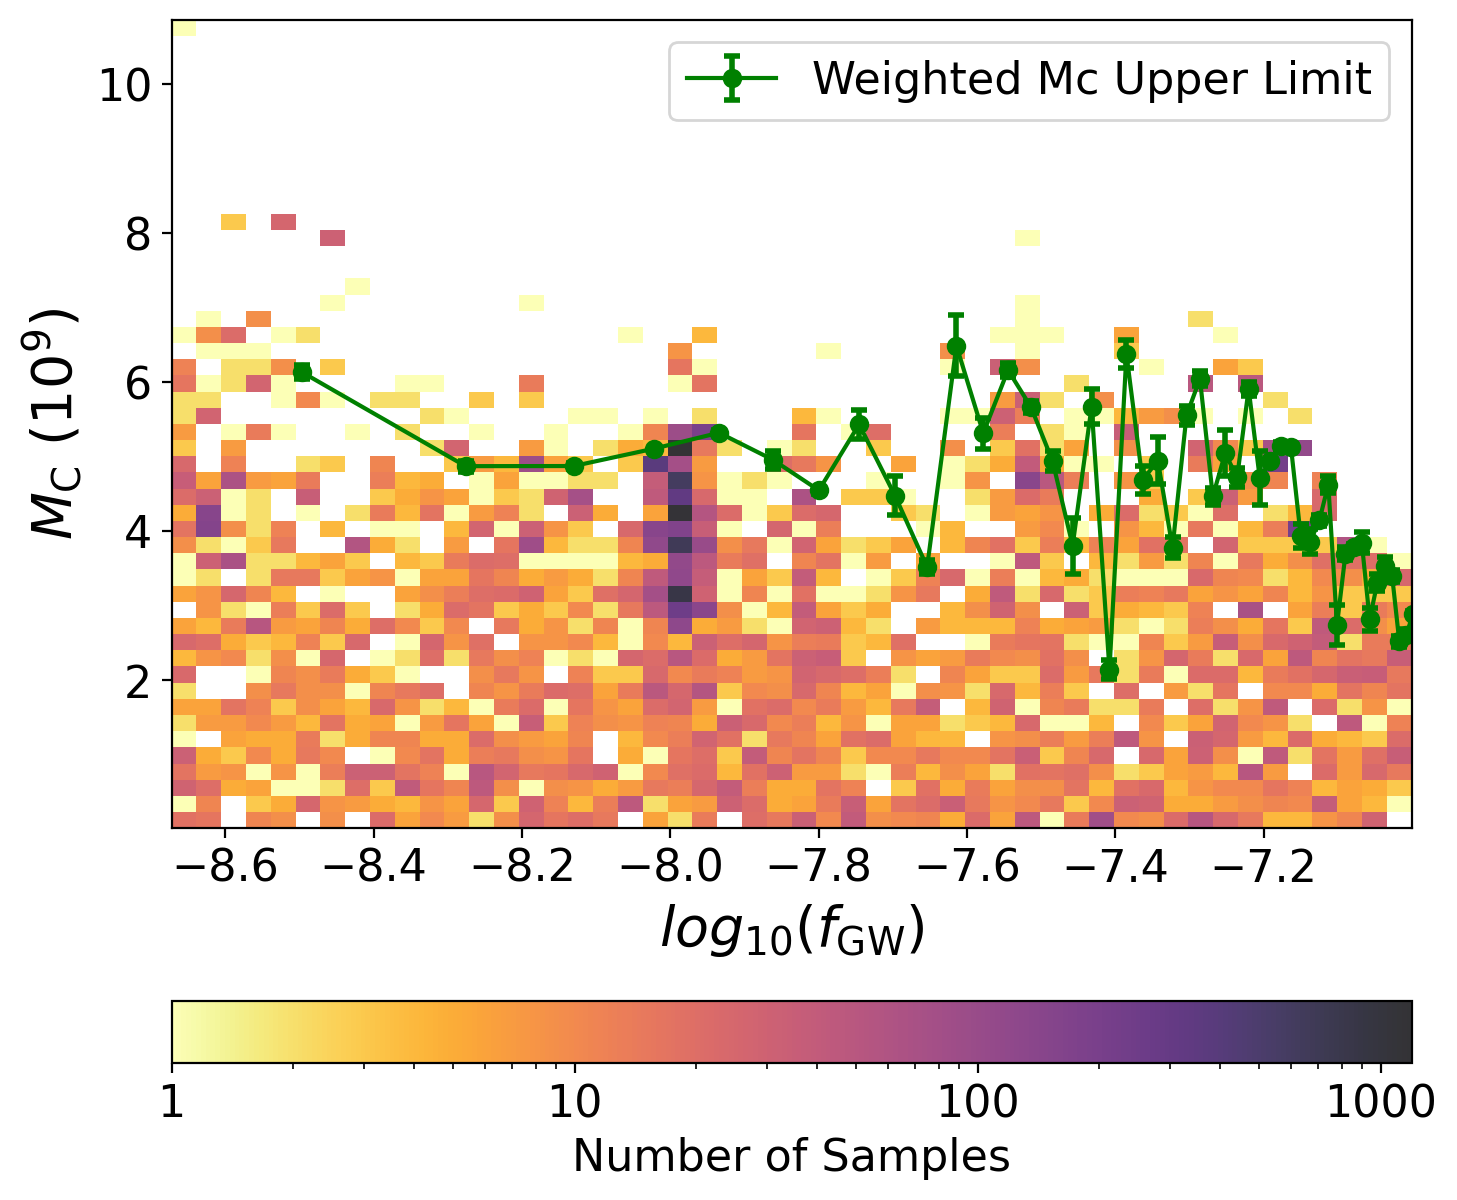

In [9]:
from matplotlib.ticker import ScalarFormatter
from matplotlib import colors

plt.rcParams['font.size'] = 16

fig, ax = plt.subplots(figsize=(8,7.5))

print(10**samples2plot[d_L_mask, 5]/1e9)
print("ULs",np.log10(ULs))
print("UL_errors",np.log10(UL_errors))

counts, xbins, ybins, image = ax.hist2d(
    samples2plot[d_L_mask, 3],   # log10(f_GW)
    (10**samples2plot[d_L_mask, 5]) / 1e9,  # Mc in 10^9 Msun
    bins=50,
    norm=colors.LogNorm(),
    alpha=0.8,
    cmap='inferno_r'
)


ax.errorbar(
    np.log10(fGW_bin_center), UL_by9, 
    yerr=ULerr_by9, 
    fmt='o', 
    color='g',
    ecolor='green',
    elinewidth=2, 
    capsize=3, 
    capthick=2, 
    linestyle='-', 
    label='Weighted Mc Upper Limit'
    
)

cbar = plt.colorbar(image, ax = ax, label='Number of Samples', orientation='horizontal')
cbar.ax.xaxis.set_major_formatter(ScalarFormatter())


#plt.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
#plt.yaxis.set_major_formatter(ScalarFormatter())
plt.ticklabel_format(style='plain', axis='y')

#plt.xlim(-8.5,-7)
#plt.ylim(7,10)
plt.xlabel('$log_{10}(f_{\mathrm{GW}}) $', fontsize = 20)
plt.ylabel('$M_{\mathrm{C}}$ $(10^{9})$', fontsize = 20)
plt.legend()


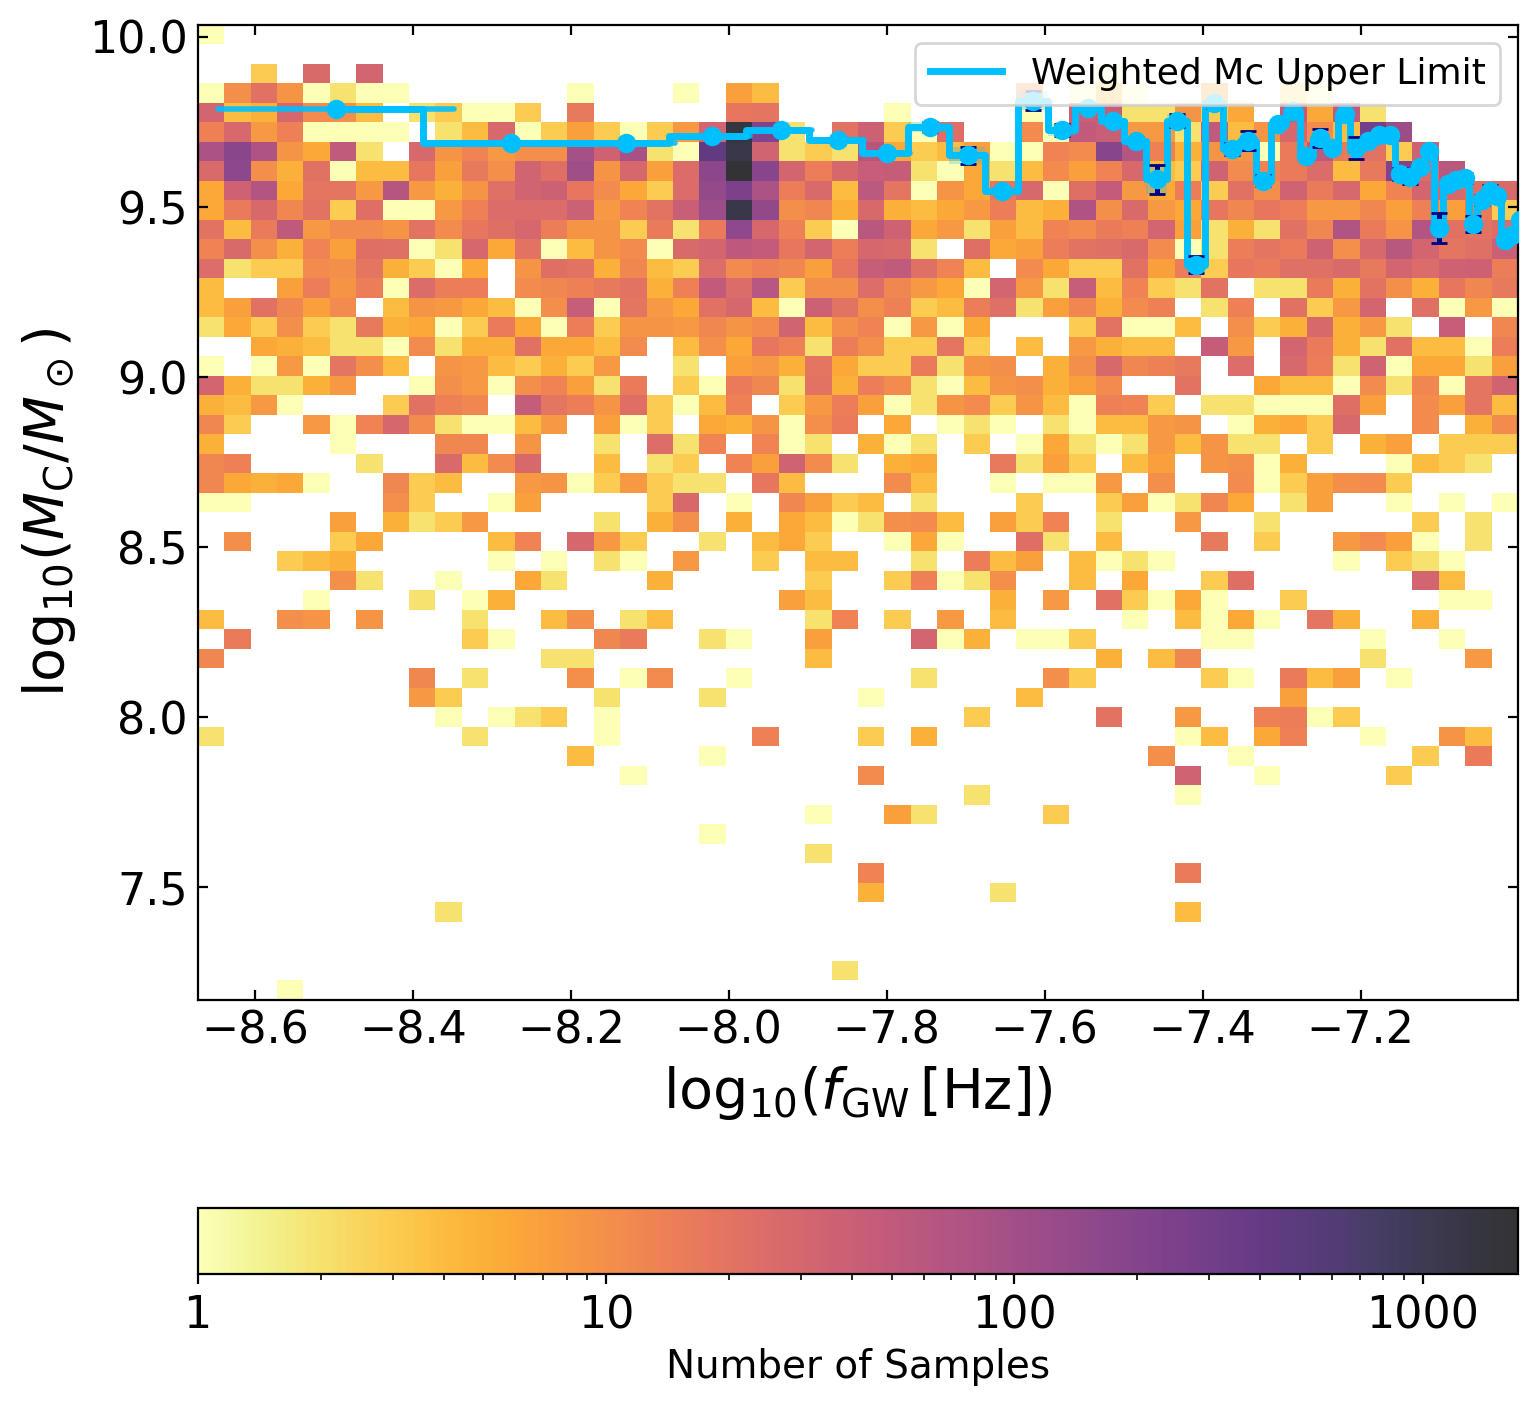

In [10]:
plt.rcParams['font.size'] = 16

fig, ax = plt.subplots(figsize=(8, 7.5))

# ---------------- 2D background histogram ---------------- #
logf = samples2plot[d_L_mask, 3]     # already log10(f_GW)
logmc = samples2plot[d_L_mask, 5]    # log10(Mc / Msun)

counts, xbins, ybins, image = ax.hist2d(
    logf, logmc,
    bins=50,
    norm=colors.LogNorm(),
    alpha=0.8,
    cmap="inferno_r"
)

# ---------------- Prepare UL data ---------------- #
UL_log = np.log10(ULs)
UL_err_log = np.array(UL_errors) / (np.array(ULs) * np.log(10))
fGW_log = np.log10(fGW_bin_center)

# Sort by frequency to ensure left→right order
sort_idx = np.argsort(fGW_log)
fGW_log = fGW_log[sort_idx]
UL_log = UL_log[sort_idx]
UL_err_log = UL_err_log[sort_idx]

# Compute bin edges and true horizontal half-widths
fGW_log_edges = np.log10(f_bin_edges)
fGW_log_binwidths = np.diff(fGW_log_edges)
# ensure number of widths matches number of bins
bin_halfwidths = fGW_log_binwidths[:len(fGW_log)] / 2

# ---------------- Step histogram for UL ---------------- #
ax.step(
    fGW_log,
    UL_log,
    where="mid",
    color="deepskyblue",
    lw=2.5,
    label="Weighted Mc Upper Limit",
    zorder=3,
)

# ---------------- Shaded UL error band ---------------- #
ax.fill_between(
    fGW_log,
    UL_log - UL_err_log,
    UL_log + UL_err_log,
    step="mid",
    color="deepskyblue",
    alpha=0.25,
    linewidth=0,
    zorder=2,
)

# ---------------- Discrete UL markers ---------------- #
ax.errorbar(
    fGW_log,
    UL_log,
    yerr=UL_err_log,
    fmt='o',
    color='deepskyblue',
    ecolor='navy',
    elinewidth=1.8,
    capsize=3,
    lw=0,
    zorder=4,
)

# ---------------- Horizontal bin-width bars ---------------- #
# compute actual bin edges in log10 space for accuracy
left_edges = fGW_log - bin_halfwidths
right_edges = fGW_log + bin_halfwidths

# each bar should exactly span its bin width horizontally
for i in range(len(fGW_log)):
    ax.hlines(
        UL_log[i],            # y position
        left_edges[i],        # start of bin
        right_edges[i],       # end of bin
        color='deepskyblue',
        lw=2,
        alpha=0.9,
        zorder=4,
        capstyle='round'
    )

# ---------------- Aesthetic adjustments ---------------- #
cbar = plt.colorbar(image, ax=ax, orientation="horizontal", pad=0.15)
cbar.set_label("Number of Samples", fontsize=14)
cbar.ax.xaxis.set_major_formatter(ScalarFormatter())

ax.tick_params(direction="in", top=True, right=True, which="both")
ax.grid(False)

plt.xlabel(r"$\log_{10}(f_{\mathrm{GW}}\, [\mathrm{Hz}])$", fontsize=20)
plt.ylabel(r"$\log_{10}(M_{\mathrm{C}} / M_\odot)$", fontsize=20)
plt.legend(frameon=True, loc="upper right", fontsize=13)
plt.tight_layout()
plt.show()